In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

## Lectura de coordenadas de modelos con diferentes semillas

In [2]:

# Asignación de los argumentos a variables correspondientes
DATASET = 'chile'
# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../data/data_people_dump_{DATASET}.csv')

# Cargar el archivo TSV de etiquetas de coordenadas
labels_coords = pd.read_csv(f'../data/labels/chile.tsv', delimiter='\t').rename(columns={'id': 'option_id'})

# Cargar el archivo CSV de coordenadas Usuarios modelo 1
coordsU_0 = pd.read_csv('results/coordsU/chile_04_01_2024_16_46_41.csv')
coordsU_0[['z1_1','z2_2']] = coordsU_0[['z2','z1']]
coordsU_0 = coordsU_0.merge(userMetadata,on='uuid')

# Cargar el archivo CSV de coordenadas Usuarios modelo 1'
coordsU_1 = pd.read_csv('results/coordsU/chile_04_01_2024_16_40_08.csv')
coordsU_1['z2'] = (1-coordsU_1['z2']).abs()
coordsU_1[['z1_1','z2_2']] = coordsU_1[['z2','z1']]
coordsU_1 = coordsU_1.merge(userMetadata,on='uuid')

# Cargar el archivo CSV de coordenadas Usuarios modelo 1''
coordsU_2 = pd.read_csv('results/coordsU/chile_05_01_2024_09_31_47.csv')
coordsU_2[['z1_1','z2_2']] = coordsU_2[['z2','z1']]
coordsU_2 = coordsU_2.merge(userMetadata,on='uuid')

# Cargar el archivo CSV de coordenadas Usuarios modelo 1'''
coordsU_3 = pd.read_csv('results/coordsU/chile_04_01_2024_16_43_10.csv')
coordsU_3[['z1_1','z2_2']] = coordsU_3[['z2','z1']]
coordsU_3 = coordsU_3.merge(userMetadata,on='uuid')

# Cargar el archivo CSV de coordenadas Usuarios modelo 1''''
coordsU_4 = pd.read_csv('results/coordsU/chile_04_01_2024_16_44_51.csv')
coordsU_4['z2'] = (1-coordsU_4['z2']).abs()
coordsU_4[['z1_1','z2_2']] = coordsU_4[['z2','z1']]
coordsU_4= coordsU_4.merge(userMetadata,on='uuid')


In [3]:
def hide_border(ax):
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
def kfold_random_forest(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=42,color='viridis'):
    # Crear el objeto MinMaxScaler para escalar las características
    scaler = MinMaxScaler()

    # Validación cruzada con 10-fold
    kf = KFold(n_splits=10, shuffle=True, random_state=semilla)
    accuracies = []
    for train_index, test_index in kf.split(train_features):
        # Dividir los datos en conjuntos de entrenamiento y prueba para esta iteración de KFold
        X_train_fold, X_test_fold = train_features[train_index], train_features[test_index]
        y_train_fold, y_test_fold = train_labels[train_index], train_labels[test_index]

        # Escalar las características de los datos de entrenamiento y prueba
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_test_fold_scaled = scaler.transform(X_test_fold)

        # Crear y entrenar el modelo de Random Forest
        classifier = RandomForestClassifier(n_estimators=n_estimators, criterion=criterion, random_state=semilla)
        classifier.fit(X_train_fold_scaled, y_train_fold)

        # Predecir y evaluar el modelo en el conjunto de prueba de esta iteración
        y_pred_fold = classifier.predict(X_test_fold_scaled)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        accuracies.append(accuracy_fold)

    # Calcular la precisión promedio de todas las iteraciones de KFold
    mean_accuracy = np.mean(accuracies)

    # Mostrar el boxplot de las precisión obtenidas
    fig, ax = plt.subplots(1,1, figsize=(10,8))
    sns.boxplot(y=accuracies, palette=color,boxprops={'alpha': 0.7},width = 0.2)
    sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)
    plt.yticks(fontsize = 15)
    ax.set_xlabel('Cross Validation Folds',fontsize=18,fontweight='bold')
    ax.set_ylabel('Accuracy',fontsize=18,fontweight='bold')
    ax.set_title("Accuracy of 10-Fold Cross Validation Based on User Coordinates",pad=24,fontweight=700,fontsize=20)
    hide_border(ax)
    # Mostrar la figura
    plt.tight_layout()
    #plt.savefig('figuras/Plot/Boxplot of SVM Accuracy with 10-Fold Cross Validation.png')
    plt.show()

    print(f"Accuracy promedio con validación cruzada 10-fold: {mean_accuracy:.2f}")



def kfold_random_forest_1(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=42,color='viridis'):
    # Crear el objeto MinMaxScaler para escalar las características
    scaler = MinMaxScaler()

    # Validación cruzada con 10-fold
    kf = KFold(n_splits=10, shuffle=True, random_state=semilla)
    accuracies = []
    for train_index, test_index in kf.split(train_features):
        # Dividir los datos en conjuntos de entrenamiento y prueba para esta iteración de KFold
        X_train_fold, X_test_fold = train_features[train_index], train_features[test_index]
        y_train_fold, y_test_fold = train_labels[train_index], train_labels[test_index]

        # Escalar las características de los datos de entrenamiento y prueba
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_test_fold_scaled = scaler.transform(X_test_fold)

        # Crear y entrenar el modelo de Random Forest
        classifier = RandomForestClassifier(n_estimators=n_estimators, criterion=criterion, random_state=semilla)
        classifier.fit(X_train_fold_scaled, y_train_fold)

        # Predecir y evaluar el modelo en el conjunto de prueba de esta iteración
        y_pred_fold = classifier.predict(X_test_fold_scaled)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        accuracies.append(accuracy_fold)

    # Calcular la precisión promedio de todas las iteraciones de KFold
    mean_accuracy = np.mean(accuracies)

    # Mostrar el boxplot de las precisión obtenidas
    fig, ax = plt.subplots(1,1, figsize=(10,8))
    sns.boxplot(y=accuracies, palette=color,boxprops={'alpha': 0.7},width = 0.2)
    sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)
    plt.yticks(fontsize = 15)
    ax.set_xlabel('Cross Validation Folds',fontsize=18,fontweight='bold')
    ax.set_ylabel('Accuracy',fontsize=18,fontweight='bold')
    ax.set_title("Accuracy of 10-Fold Cross Validation Based on PCA",pad=24,fontweight=700,fontsize=20)
    hide_border(ax)
    # Mostrar la figura
    plt.tight_layout()
    #plt.savefig('figuras/Plot/Boxplot of SVM Accuracy with 10-Fold Cross Validation.png')
    plt.show()

    print(f"Accuracy promedio con validación cruzada 10-fold: {mean_accuracy:.2f}")




### Preprocesamiento

In [4]:

def label_region(region):
    """
    Define un identificador para las regiones
    """
    if region==0:
        return 0
    if region=='Arica y Parinacota':
        return 1
    elif region == 'Tarapacá':
        return 2
    elif region =='Antofagasta':
        return 3
    elif region =='Atacama':
        return 4
    elif region =='Coquimbo':
        return 5
    elif region =='Valparaíso':
        return 6
    elif region =='Metropolitana de Santiago' or region == 'Santiago Metropolitan':
        return 7
    elif region =="O'Higgins":
        return 8
    elif region =='Maule':
        return 9
    elif region =='Ñuble':
        return 10
    elif region =='Biobío' or region =='Biobio':
        return 11
    elif region =='Araucanía':
        return 12
    elif region =='Los Ríos':
        return 13
    elif region =='Los Lagos':
        return 14
    elif region =='Aysén':
        return 15
    elif region =='Magallanes':
        return 16
    elif region =='Outside of Chile' or region=='Fuera de Chile':
        return 17

femenino = coordsU_0[coordsU_0['sex']=='Femenino'].index
coordsU_0['sex'] = 1
coordsU_0.loc[femenino,'sex'] = 0
coordsU_0['region'] = coordsU_0['region'].apply(lambda x:label_region(x))

femenino = coordsU_1[coordsU_1['sex']=='Femenino'].index
coordsU_1['sex'] = 1
coordsU_1.loc[femenino,'sex'] = 0
coordsU_1['region'] = coordsU_1['region'].apply(lambda x:label_region(x))

femenino = coordsU_2[coordsU_2['sex']=='Femenino'].index
coordsU_2['sex'] = 1
coordsU_2.loc[femenino,'sex'] = 0
coordsU_2['region'] = coordsU_2['region'].apply(lambda x:label_region(x))

femenino = coordsU_3[coordsU_3['sex']=='Femenino'].index
coordsU_3['sex'] = 1
coordsU_3.loc[femenino,'sex'] = 0
coordsU_3['region'] = coordsU_3['region'].apply(lambda x:label_region(x))

femenino = coordsU_4[coordsU_4['sex']=='Femenino'].index
coordsU_4['sex'] = 1
coordsU_4.loc[femenino,'sex'] = 0
coordsU_4['region'] = coordsU_4['region'].apply(lambda x:label_region(x))

# 1.Semilla 1

## 1.1  Coordenadas z1 y z2

In [5]:
semilla = 101
# Labels son los valores que queremos predecir
coordsU_0 = coordsU_0[coordsU_0['politica']!=5]
label = coordsU_0['politica']
label = [0 if label < 5 else 1 for label in label]
train_labels = np.array(label)



# axis 1 se refiere a las columnas
train_features = coordsU_0.drop(['z1', 'z2','id', 
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=101)

KeyboardInterrupt: 

## 1.2  PCA

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:83: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


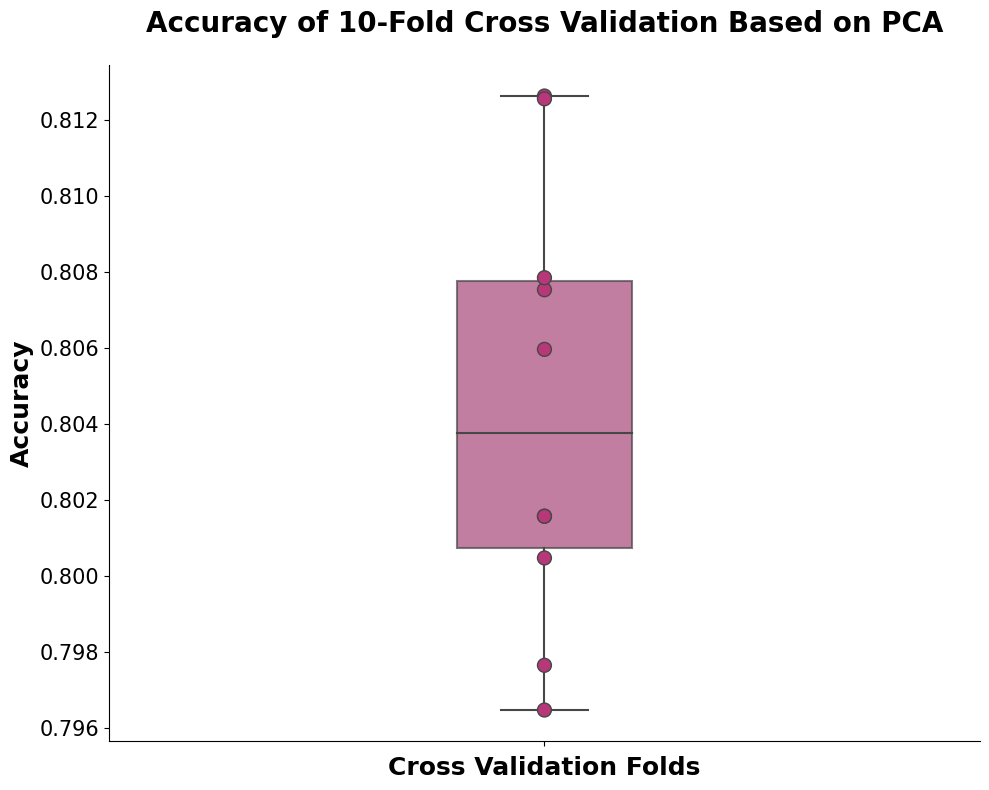

Accuracy promedio con validación cruzada 10-fold: 0.80


In [6]:
# Seleccionar las columnas z1 y z2 para el análisis PCA
columns = ['z1_1', 'z2_2']

# Inicializar el modelo de PCA con un componente principal
pca_0 = PCA(n_components=1)
# Aplicar PCA a los datos y obtener la nueva representación en una dimensión
result_0 = pca_0.fit_transform(coordsU_0[columns])
coordsU_0['PCA'] = result_0
train_features = coordsU_0.drop(['z1', 'z2','id', 'z1_1', 'z2_2',
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest_1(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla,color='magma')

# 2.Semilla 2

## 2.1  Coordenadas z1 y z2

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:37: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


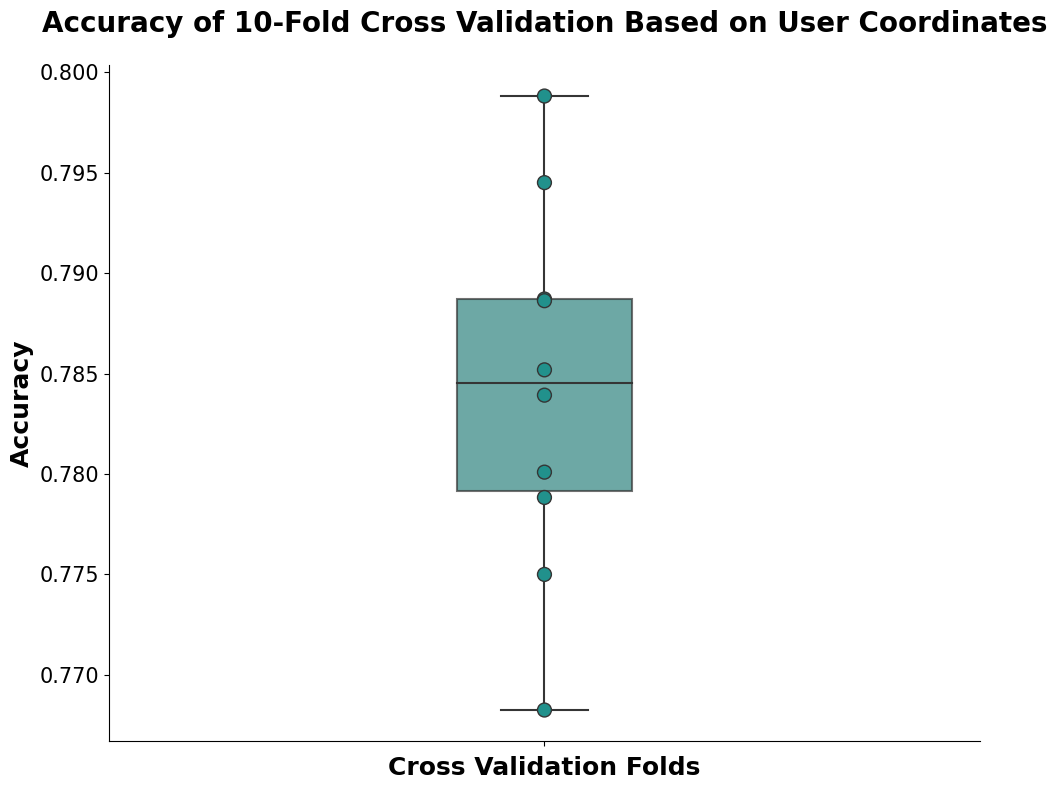

Accuracy promedio con validación cruzada 10-fold: 0.78


In [7]:


semilla = 201
# Labels son los valores que queremos predecir
coordsU_1 = coordsU_1[coordsU_1['politica']!=5]
label = coordsU_1['politica']
label = [0 if label < 5 else 1 for label in label]
train_labels = np.array(label)


# axis 1 se refiere a las columnas
train_features = coordsU_1.drop(['z1', 'z2','id', 
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla)

## 2.2  PCA

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:83: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


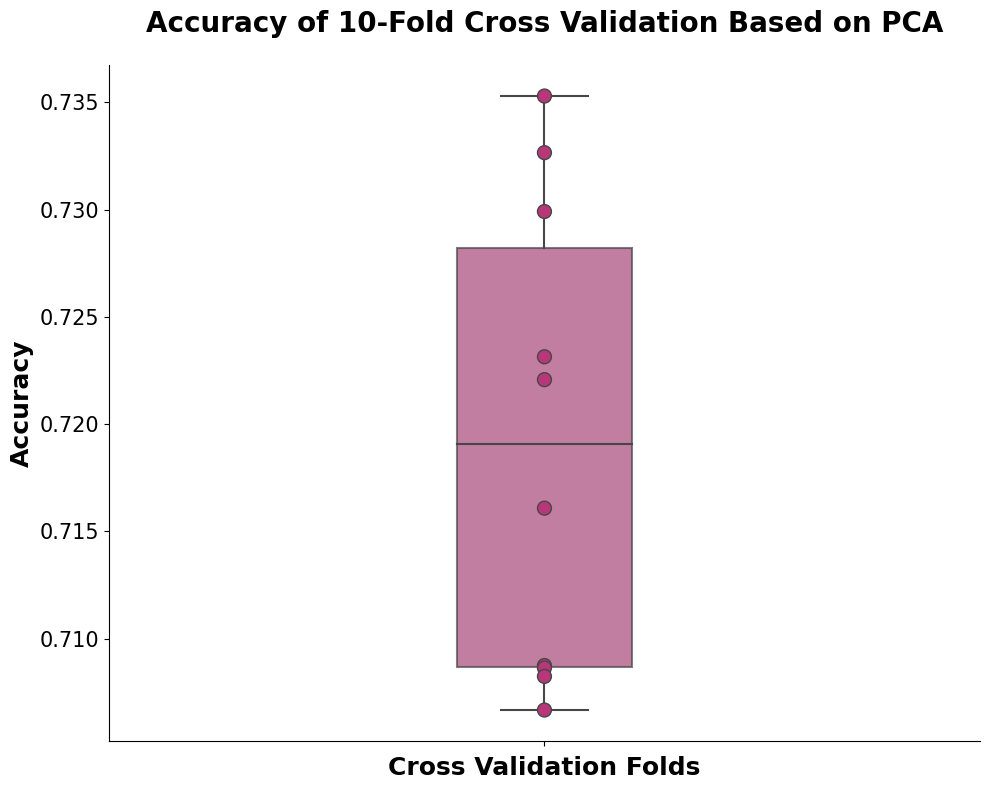

Accuracy promedio con validación cruzada 10-fold: 0.72


In [8]:

# Seleccionar las columnas z1 y z2 para el análisis PCA
columns = ['z1_1', 'z2_2']

# Inicializar el modelo de PCA con un componente principal
pca_1 = PCA(n_components=1)
# Aplicar PCA a los datos y obtener la nueva representación en una dimensión
result_1 = pca_1.fit_transform(coordsU_1[columns])
coordsU_1['PCA'] = result_1
train_features = coordsU_1.drop(['z1', 'z2','id', 'z1_1', 'z2_2',
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest_1(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla,color='magma')

# 3.Semilla 3

## 3.1  Coordenadas z1 y z2

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:37: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


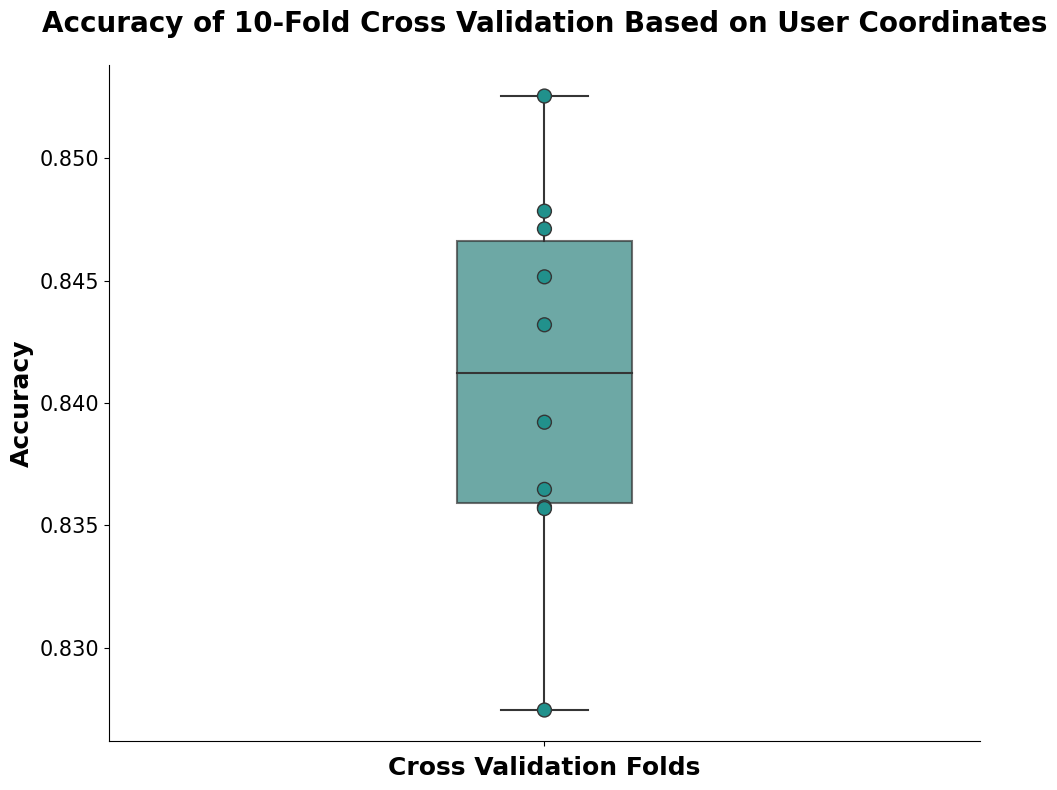

Accuracy promedio con validación cruzada 10-fold: 0.84


In [9]:

semilla = 301
# Labels son los valores que queremos predecir
coordsU_2 = coordsU_2[coordsU_2['politica']!=5]
label = coordsU_2['politica']
label = [0 if label < 5 else 1 for label in label]
train_labels = np.array(label)


# axis 1 se refiere a las columnas
train_features = coordsU_2.drop(['z1', 'z2','id', 
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla)

## 3.2  PCA

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:83: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


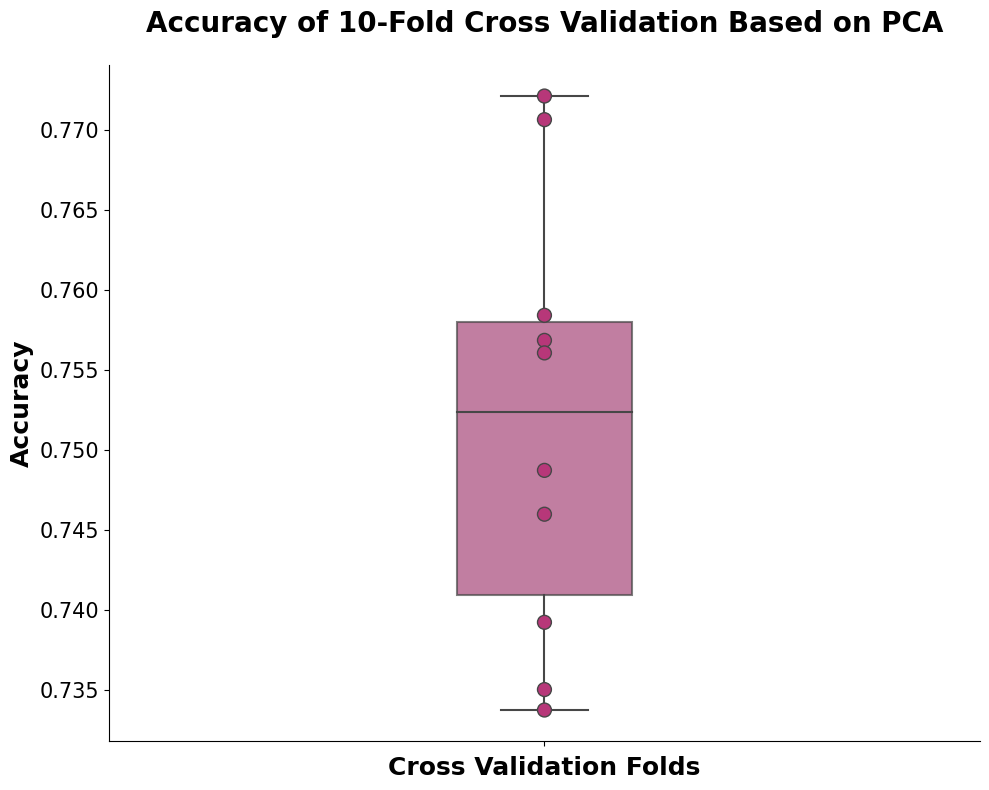

Accuracy promedio con validación cruzada 10-fold: 0.75


In [10]:

# Seleccionar las columnas z1 y z2 para el análisis PCA
columns = ['z1_1', 'z2_2']

# Inicializar el modelo de PCA con un componente principal
pca_2 = PCA(n_components=1)
# Aplicar PCA a los datos y obtener la nueva representación en una dimensión
result_2 = pca_2.fit_transform(coordsU_2[columns])
coordsU_2['PCA'] = result_2
train_features = coordsU_2.drop(['z1', 'z2','id', 'z1_1', 'z2_2',
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest_1(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla,color='magma')

# 4.Semilla 4

## 4.1  Coordenadas z1 y z2

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:37: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


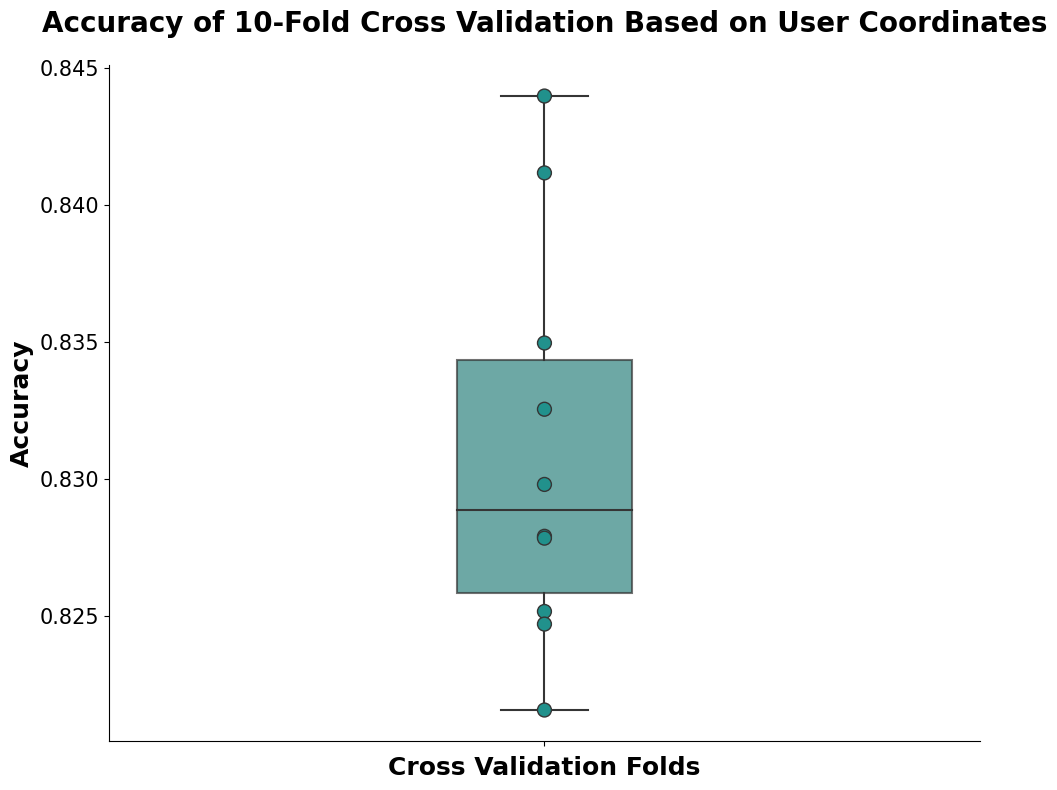

Accuracy promedio con validación cruzada 10-fold: 0.83


In [11]:
semilla = 401
# Labels son los valores que queremos predecir
coordsU_3 = coordsU_3[coordsU_3['politica']!=5]
label = coordsU_3['politica']
label = [0 if label < 5 else 1 for label in label]
train_labels = np.array(label)


# axis 1 se refiere a las columnas
train_features = coordsU_3.drop(['z1', 'z2','id', 
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla)

## 4.2  PCA

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:83: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


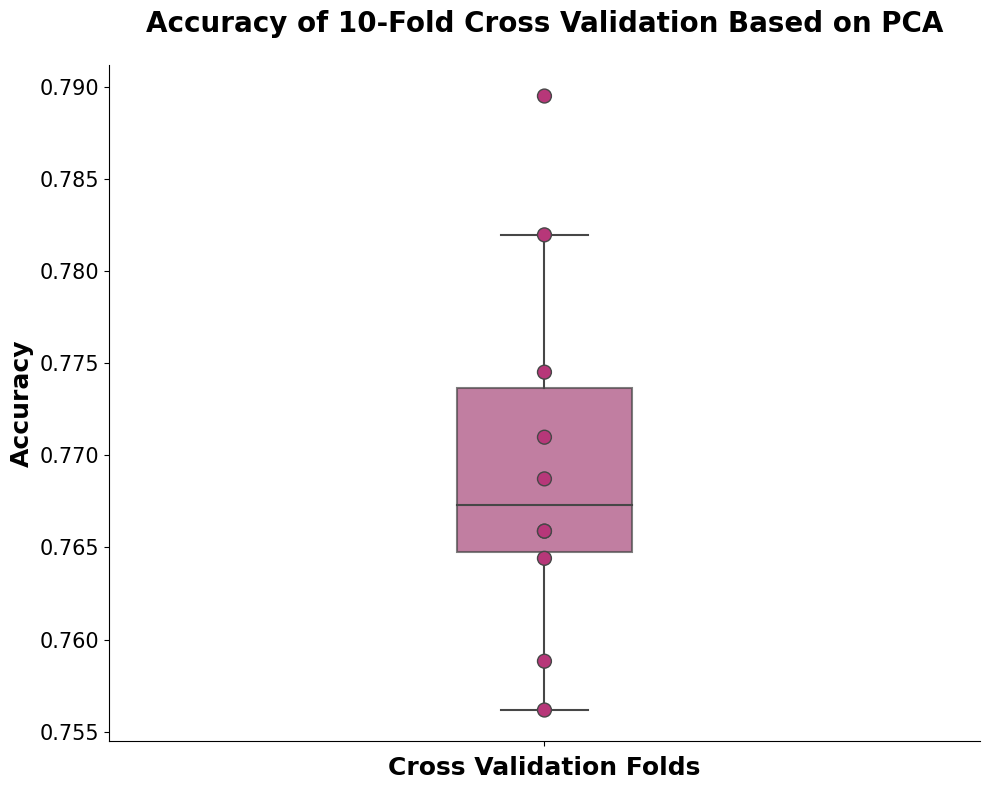

Accuracy promedio con validación cruzada 10-fold: 0.77


In [12]:
# Seleccionar las columnas z1 y z2 para el análisis PCA
columns = ['z1_1', 'z2_2']

# Inicializar el modelo de PCA con un componente principal
pca_3 = PCA(n_components=1)
# Aplicar PCA a los datos y obtener la nueva representación en una dimensión
result_3 = pca_3.fit_transform(coordsU_3[columns])
coordsU_3['PCA'] = result_3
train_features = coordsU_3.drop(['z1', 'z2','id', 'z1_1', 'z2_2',
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest_1(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla,color='magma')

# 5.Semilla 5

## 5.1  Coordenadas z1 y z2

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:37: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


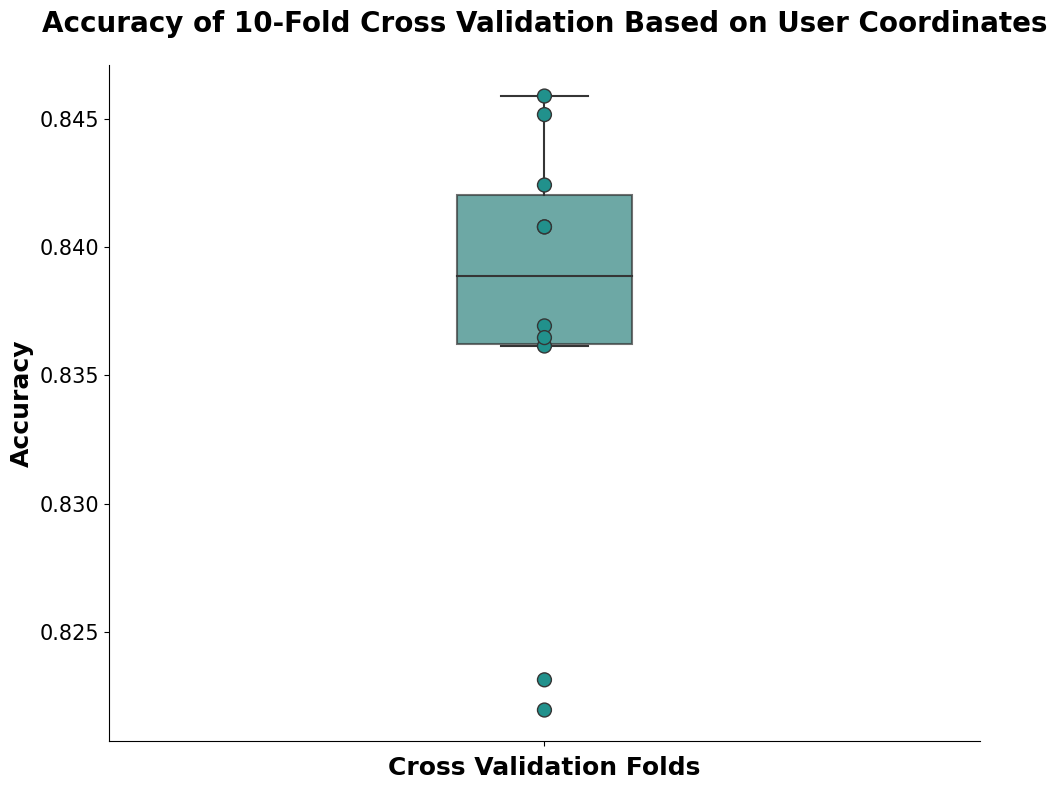

Accuracy promedio con validación cruzada 10-fold: 0.84


In [13]:

semilla = 501
# Labels son los valores que queremos predecir
coordsU_4 = coordsU_4[coordsU_4['politica']!=5]
label = coordsU_4['politica']
label = [0 if label < 5 else 1 for label in label]
train_labels = np.array(label)


# axis 1 se refiere a las columnas
train_features = coordsU_4.drop(['z1', 'z2','id', 
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla)

## 5.2  PCA

C:\Users\cmurua\AppData\Local\Temp\ipykernel_28208\2882439716.py:83: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(y=accuracies,palette=color, dodge=True,size=10,jitter=0,linewidth=1)


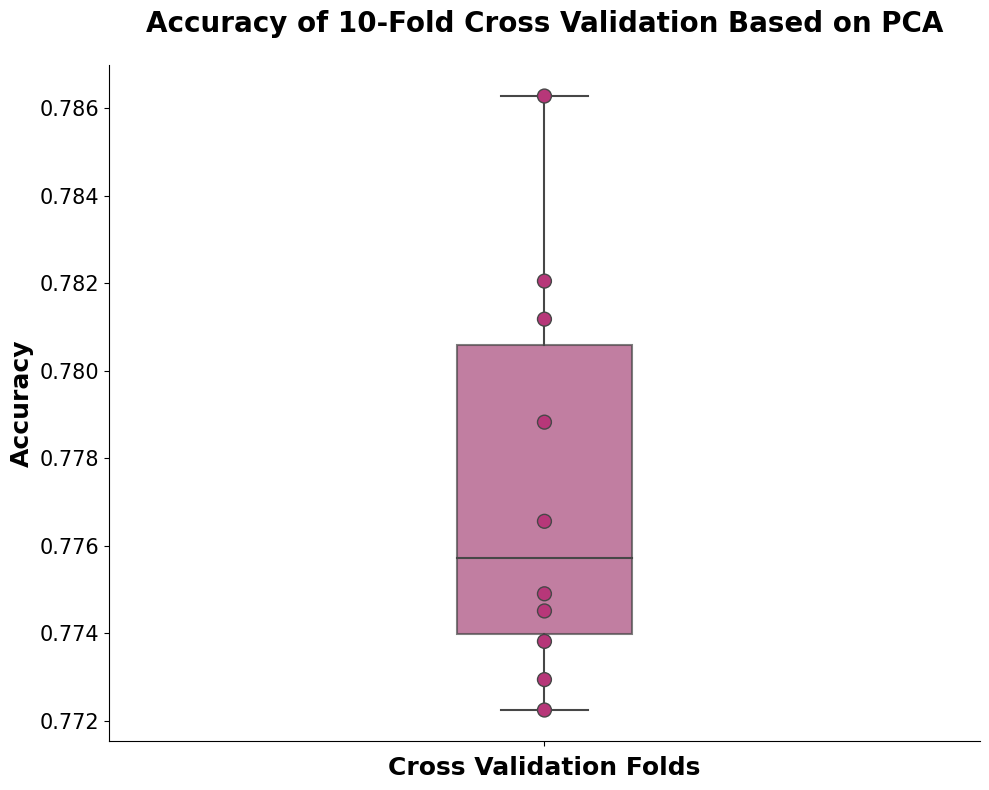

Accuracy promedio con validación cruzada 10-fold: 0.78


In [14]:
# Seleccionar las columnas z1 y z2 para el análisis PCA
columns = ['z1_1', 'z2_2']

# Inicializar el modelo de PCA con un componente principal
pca_4 = PCA(n_components=1)
# Aplicar PCA a los datos y obtener la nueva representación en una dimensión
result_4 = pca_4.fit_transform(coordsU_4[columns])
coordsU_4['PCA'] = result_4
train_features = coordsU_4.drop(['z1', 'z2','id', 'z1_1', 'z2_2',
       'politica', 'datetime', 'score', 'ip_hash','politica','uuid'], axis=1)
train_features = np.array(train_features)

kfold_random_forest_1(train_features, train_labels, n_estimators=2000, criterion='entropy', semilla=semilla,color='magma')